# T435 — blind ARA binary-identity inversion

**TL;DR:** the sealed waveform-only inversion recovered the two-hole axis, the common closing relation, and correlated child radial histories, but its three-landmark common-horizon clock was 37.54 M late. The frozen verdict is **PARTIAL**, and the individual child-share magnitudes remain unresolved.

## Context & methods

The prediction stage read only the combined SXS strain modes. It used `phase(h22)/2` for the antipodal child axis, odd/even modal imbalance for the unordered child split, and reverse cadence rank for the remaining relation. The prediction NPZ was hashed before the individual A/B and common C horizons were revealed. See `T435_FROZEN_PROTOCOL.md` for the complete predeclared rules.

## Data

Source: SXS:BBH:0305 Lev6, Zenodo record 13182440. Inference used `Strain_N4`; scoring used horizon coordinate centers and masses. Time is in simulation units M. This is a numerical-relativity crosswalk, not independent observational evidence.

In [1]:
import hashlib, json
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
RESULTS = ROOT / 'results'
scored = json.loads((RESULTS / 'T435_SCORED_RESULT.json').read_text())
sealed = (RESULTS / 'T435_PREDICTION_SHA256.txt').read_text().splitlines()[0].split()[-1]
current = hashlib.sha256((RESULTS / 'T435_WAVEFORM_ONLY_PREDICTION.npz').read_bytes()).hexdigest()
assert sealed == current
print('prediction seal verified:', current)
print('frozen result:', scored['result'])

prediction seal verified: e54f0c397bcb273fe77eab9887c97f453a66412d80d69843ffe7b7c94a8fd5b9
frozen result: PARTIAL


## Results

In [2]:
m = scored['metrics']
rows = [
    ('Orientation coherence', m['orientation_axis_coherence'], 0.80, scored['gates']['orientation']),
    ('Unhalved control', m['unhalved_phase_control_coherence'], None, None),
    ('Relation Spearman', m['relation_spearman'], 0.70, scored['gates']['relation']),
    ('Shift control', m['circular_shift_control_spearman'], None, None),
    ('Child-radius median Spearman', m['child_radius_median_spearman'], 0.50, scored['gates']['child_radii']),
    ('Child-share MAE', m['child_share_mean_absolute_error'], None, None),
    ('Handover error / M', m['handover_absolute_error'], m['parent_waveform_cycle_at_prediction'], scored['gates']['handover_timing']),
]
display(pd.DataFrame(rows, columns=['metric', 'value', 'frozen threshold', 'pass']))

,metric,value,frozen threshold,pass
0,Orientation coherence,0.994211,0.800000,True
1,Unhalved control,0.006188,NaN,None
2,Relation Spearman,0.999559,0.700000,True
3,Shift control,-0.333586,NaN,None
4,Child-radius median Spearman,0.999376,0.500000,True
5,Child-share MAE,0.085784,NaN,None
6,Handover error / M,37.542193,11.371039,False


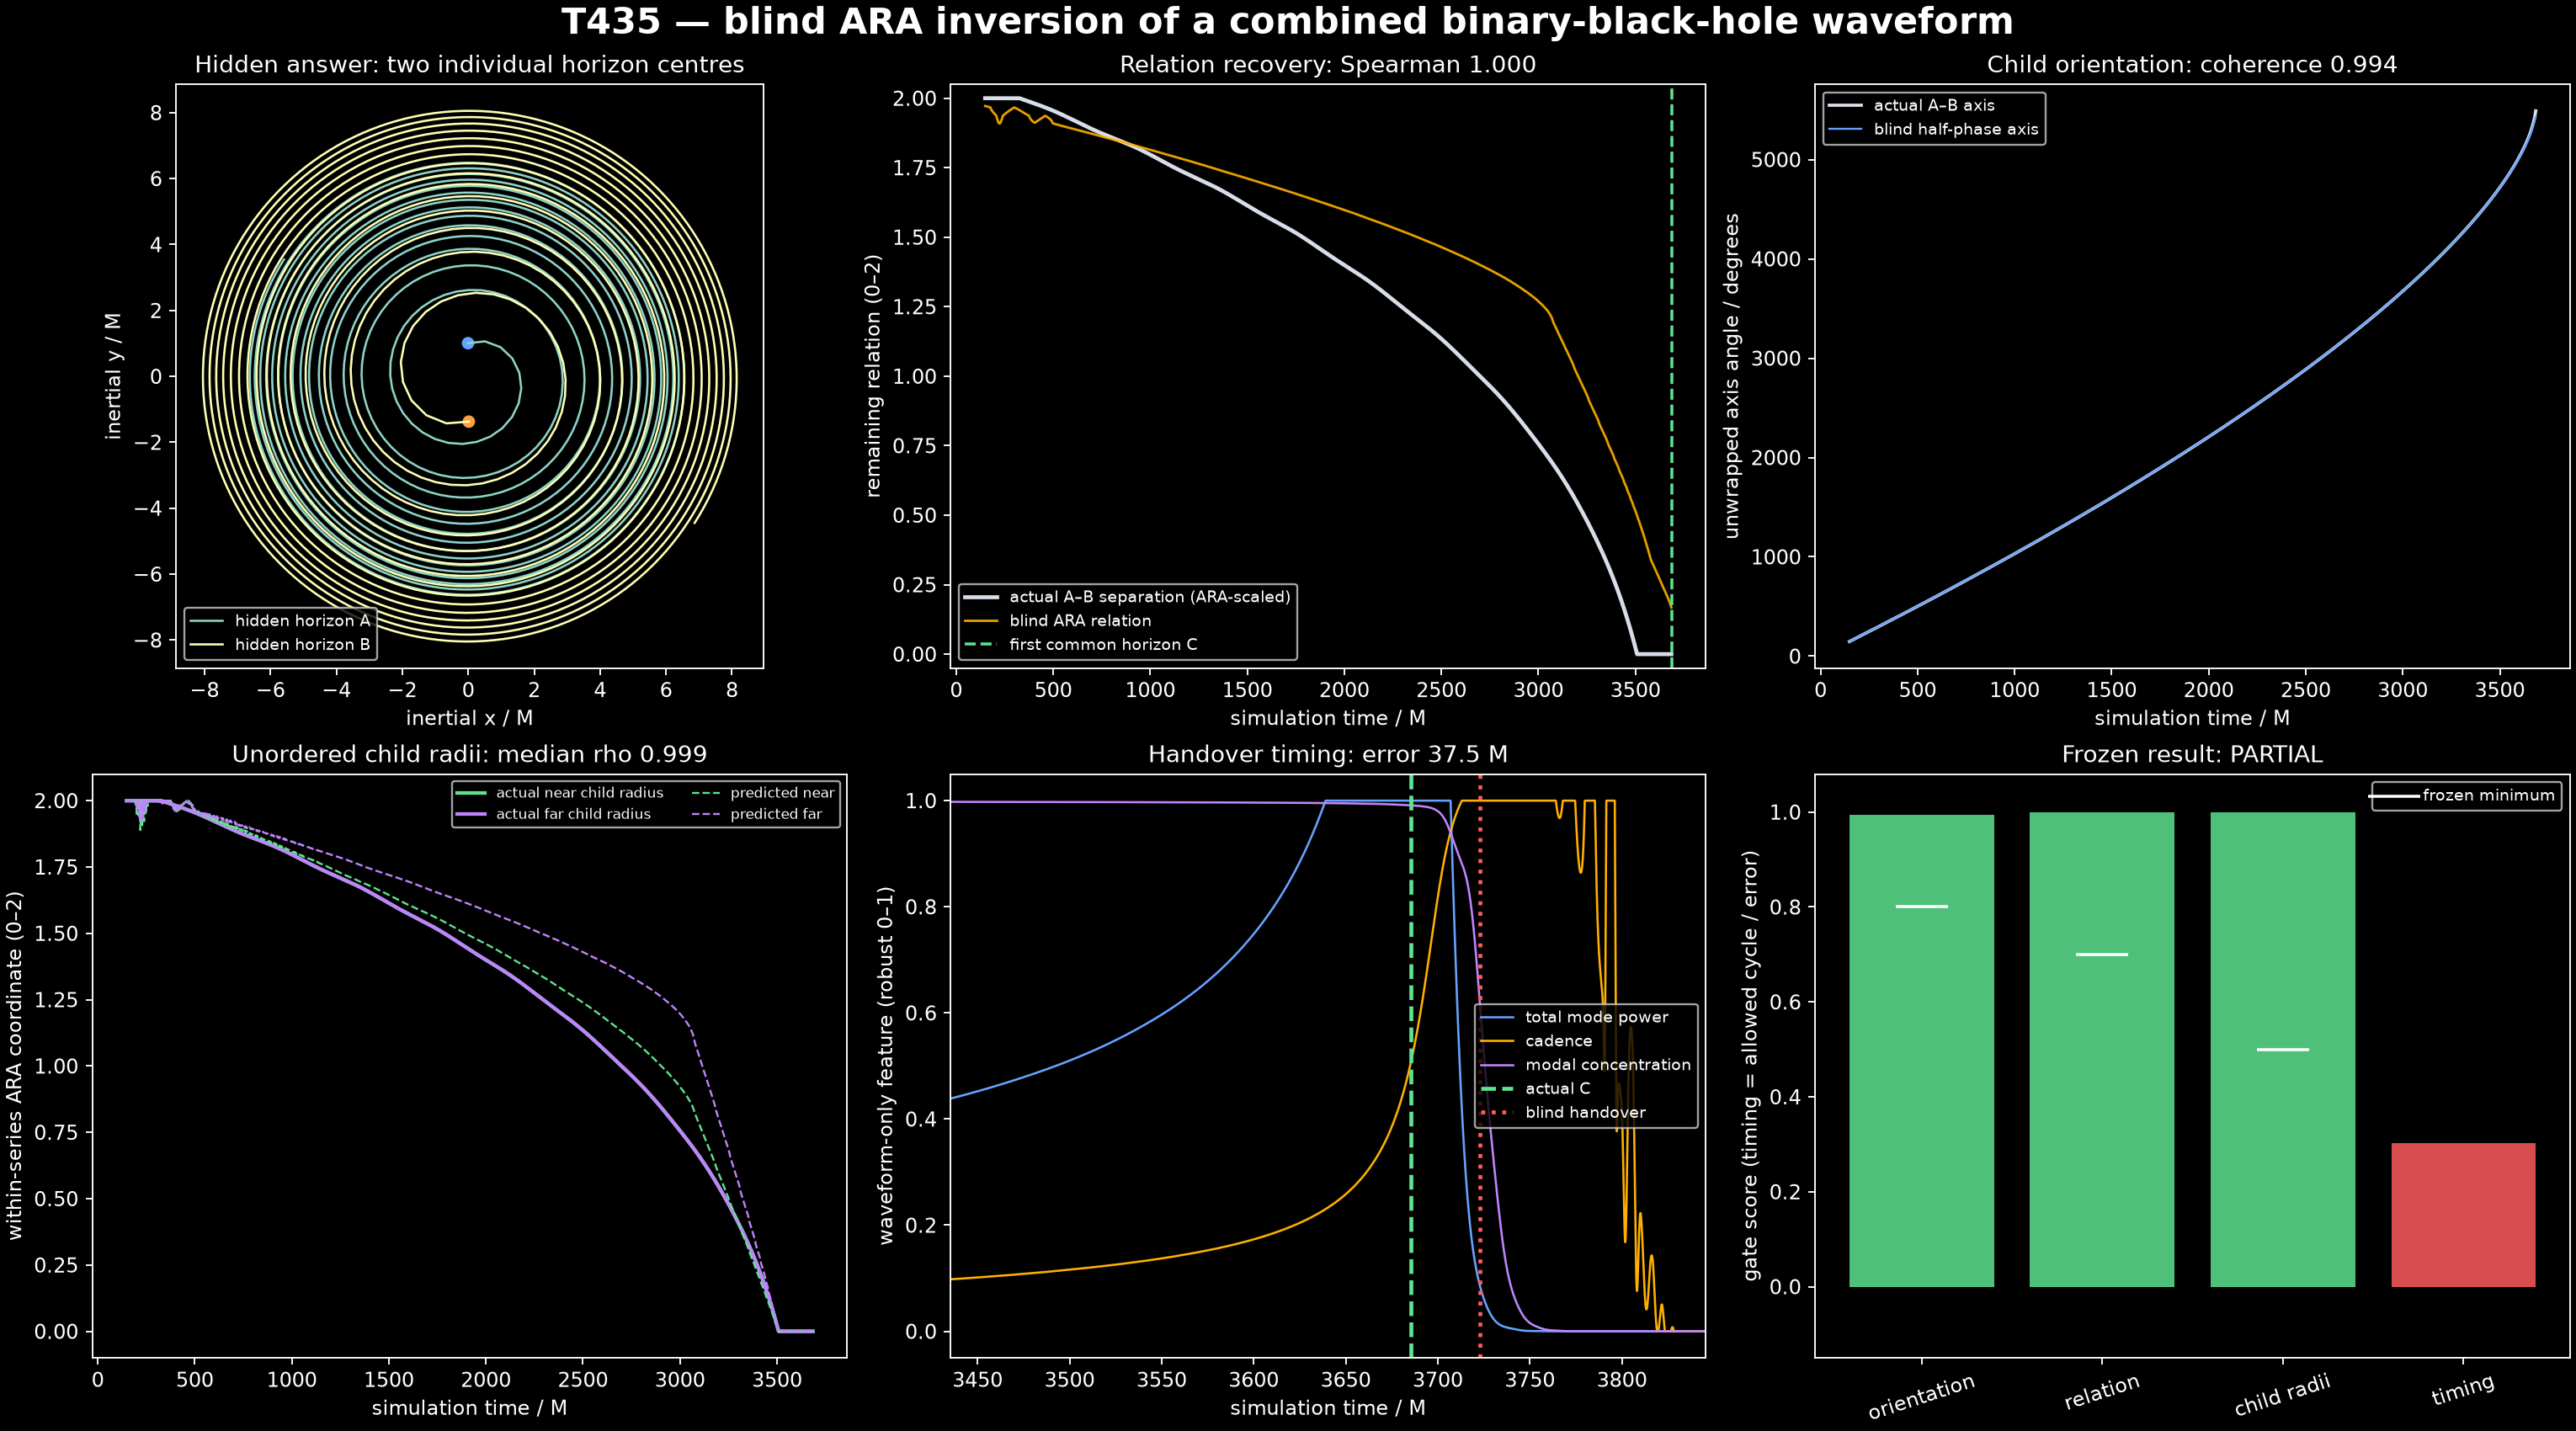

In [3]:
display(Image(filename=str(RESULTS / 'T435_BLIND_BINARY_INVERSION_AUDIT.png'), width=1200))

## Takeaways

1. The ARA half-phase/octave operation selected the correct two-child axis; the unhalved control nearly erased coherence.
2. Cadence ordering recovered the A–B closing relation, but its near-perfect rank score does not establish absolute distance.
3. The two radial histories share that closing trend. The 0.0858 child-share error means the full identities are not yet separated.
4. The frozen median handover clock failed even though the total-power peak alone was close; that post-result observation cannot rescue the gate.
5. The next decisive test is a multi-simulation holdout that predicts hidden mass contrast from one fixed waveform-only child-split mapping.